In [1]:
# imports
import os
from google.colab import userdata
from huggingface_hub import login
from datasets import load_dataset, Dataset
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np
import random

In [2]:
hf_token = userdata.get('HF_TOKEN')
login(hf_token)

In [3]:
dataset = load_dataset("medalpaca/medical_meadow_medical_flashcards",
                       split = "train")
len(dataset)


33955

In [4]:
# while this dataset should already be curated, let's still check for missing values
missing_data = []
for idx, elem in enumerate(dataset):
  if not all((elem['input'], elem['output'], elem['instruction'])) not in dict(elem).keys():
    missing_data.append(idx)
    continue
  if any((elem['input'] == '', elem['output'] == '', elem['instruction'] == '')):
    missing_data.append(idx)

In [5]:
len(missing_data)

408

In [6]:
dataset[missing_data[0]]

{'input': '',
 'output': 'There seems to be an error in the question and answer pair you provided. The virulence factors associated with Mumps are actually the surface proteins HN (hemagglutinin-neuraminidase) and F (fusion) protein.',
 'instruction': 'Answer this question truthfully'}

In [7]:
dataset[missing_data[-1]]

{'input': '', 'output': '', 'instruction': 'Answer this question truthfully'}

In [8]:
dataset_arr = np.array(dataset)
filtered_arr = np.delete(dataset_arr, missing_data)
dataset = filtered_arr.tolist()

In [9]:
len(dataset)

33547

In [10]:
def lengths(dataset: list, key: str, split: str = 'chars', bins: list = [450, 30]) -> None:
  """
  Render a distribution of text lengths given a key
  Args:
    dataset: data
    key: key of the dataset
    split: splitting the items by number of characters or words
    bins: bin parameters of a histogram
  """
  if split == 'chars':
    lengths = [len(item[key]) for item in dataset]
  elif split == 'words':
    lengths = [len(item[key].split(' ')) for item in dataset]
  else:
    raise ValueError('the split argument must be of value chars or words')
  plt.figure(figsize=(7, 3))
  plt.title(f"Lengths of {key} by number of {split}: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
  plt.xlabel(f'Length ({split})')
  plt.ylabel('Count')
  plt.hist(lengths, rwidth=0.7, color="lightblue", bins=range(0, bins[0], bins[1]))
  plt.show()


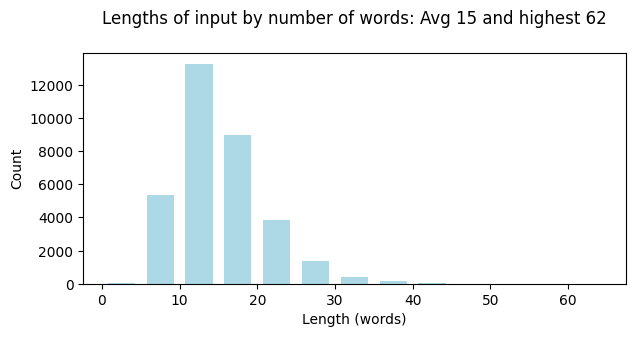

In [11]:
# checking if I would need to clip tokens
lengths(dataset, 'input', split='words', bins=[70, 5])

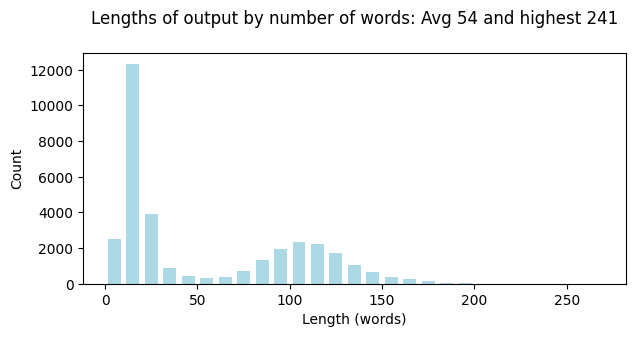

In [13]:
# probably I could try a split at 256, but the distribution is bimodal so shouldn't do 128
lengths(dataset, 'output', split='words', bins=[280, 10])

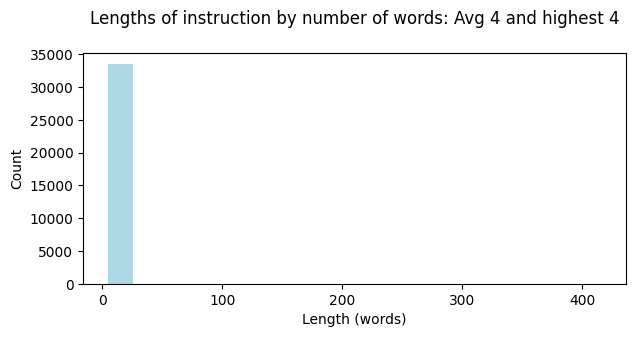

In [14]:
# no issues here, but then it's just the same instruction everywhere
lengths(dataset, 'instruction', split='words')

In [15]:
from transformers import AutoTokenizer
BASE_MODEL = "meta-llama/Llama-3.2-3B"
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

In [16]:
# System prompt to ground the AI's persona
medical_prompt = """Below is an instruction that describes a task, paired with an input that provides further context.
Write a response that appropriately completes the request.

### Instruction:
{}

### Input:
{}

### Response:
{}"""

EOS_TOKEN = tokenizer.eos_token
def format_prompts(examples):
    instructions = examples["instruction"]
    inputs       = examples["input"]
    outputs      = examples["output"]
    texts = []
    for instruction, input_text, output in zip(instructions, inputs, outputs):
        text = medical_prompt.format(instruction, input_text, output) + EOS_TOKEN
        texts.append(text)
    return { "text" : texts }

dataset = Dataset.from_list(dataset)
dataset = dataset.map(format_prompts, batched = True)


Map:   0%|          | 0/33547 [00:00<?, ? examples/s]

In [17]:
dataset[0]

{'input': 'What is the relationship between very low Mg2+ levels, PTH levels, and Ca2+ levels?',
 'output': 'Very low Mg2+ levels correspond to low PTH levels which in turn results in low Ca2+ levels.',
 'instruction': 'Answer this question truthfully',
 'text': 'Below is an instruction that describes a task, paired with an input that provides further context. \nWrite a response that appropriately completes the request.\n\n### Instruction:\nAnswer this question truthfully\n\n### Input:\nWhat is the relationship between very low Mg2+ levels, PTH levels, and Ca2+ levels?\n\n### Response:\nVery low Mg2+ levels correspond to low PTH levels which in turn results in low Ca2+ levels.<|end_of_text|>'}

In [18]:
username = "mess1989"
dataset_name = f"{username}/medicalflashcards_full"
dataset.push_to_hub(dataset_name)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/34 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########| 14.0MB / 14.0MB            

CommitInfo(commit_url='https://huggingface.co/datasets/mess1989/medicalflashcards_full/commit/7dce25b439b02cf3d9359dfb84a7c8ac5af69a10', commit_message='Upload dataset', commit_description='', oid='7dce25b439b02cf3d9359dfb84a7c8ac5af69a10', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/mess1989/medicalflashcards_full', endpoint='https://huggingface.co', repo_type='dataset', repo_id='mess1989/medicalflashcards_full'), pr_revision=None, pr_num=None)